# Multi-Signal LSTM Forecast Notebook

This notebook trains `price`, `load`, and `pv` LSTM forecasters.

Goals:
- keep one editable config block per signal
- show a clear epoch progress bar for each signal
- plot loss and prediction charts immediately after each signal finishes
- optionally create one combined weekly summary plot at the end


In [1]:
from pathlib import Path
import sys
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 启用 IPython 自动重载，修改源码后无需重启内核
try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except Exception:
    pass

# 向上查找项目根目录（以 configs 文件夹为标志）
project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "configs").exists():
    project_root = project_root.parent
if not (project_root / "configs").exists():
    raise RuntimeError("Could not locate the project root.")
# 将项目根目录加入模块搜索路径
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
project_root

WindowsPath('C:/Users/10856/Desktop/GithubProject/MADRL_ESS')

In [ ]:
# Import runtime helpers.
from IPython.display import display

from scripts.utils.forecast_shared_preset import get_managed_lstm_forecast_controls
from scripts.utils.torch_runtime import configure_torch_runtime, describe_device

# Import the mainline experiment config factory.
from configs import compose_experiment_config

# Import forecast artifact helpers and LSTM training utilities.
from predictors.artifacts import get_weekly_forecast_plot_path
from predictors.training import (
    _collect_lstm_artifact_inventory,
    collect_available_lstm_artifacts,
    plot_signal_training_report,
    plot_weekly_forecasts,
    resolve_signal_csv_source,
    resolve_signal_training_settings,
    train_signal_lstm,
)


## 1. Runtime and Per-Signal Settings

Keep shared settings and per-signal overrides separate so students can edit them quickly.


In [3]:
# Shared runtime settings
runtime_mode = "performance"          # "performance" for speed, "strict_reproducibility" for determinism
seed = 0
device_request = None                 # None selects CUDA automatically when available
require_cuda = False

FORECAST_CONTROLS = get_managed_lstm_forecast_controls(
    artifact_root=project_root / "artifacts" / "forecast" / "lstm",
    auto_train_missing=True,
)

# Signal order
signal_order = list(FORECAST_CONTROLS["target_signals"])
load_model_mode = str(FORECAST_CONTROLS["load_model_mode"])
load_time_feature_mode = str(FORECAST_CONTROLS["load_time_feature_mode"])
pv_time_feature_mode = str(FORECAST_CONTROLS["pv_time_feature_mode"])
load_hybrid_mode = str(FORECAST_CONTROLS["load_hybrid_mode"])
load_baseline_mode = str(FORECAST_CONTROLS["load_baseline_mode"])

# Component split: train separate LSTMs for household & heatpump, sum at inference
load_component_split = bool(FORECAST_CONTROLS["load_component_split"])
load_scaler_type = str(FORECAST_CONTROLS["load_scaler_type"])


# Shared sequence-window settings
shared_settings = {
    "future_horizon": int(FORECAST_CONTROLS["future_horizon"]),
    "history_window": int(FORECAST_CONTROLS["history_window"]),
    "artifact_root": Path(FORECAST_CONTROLS["artifact_root"]),
}

# Per-signal training overrides
signal_training_overrides = dict(FORECAST_CONTROLS["signal_training_overrides"])


In [4]:
# Compose the mainline experiment config for LSTM training.
cfg = compose_experiment_config(
    forecast_type="lstm",
    data_dir=project_root / "data",
    runtime_mode=runtime_mode,
    seed=seed,
    require_cuda=require_cuda,
)
cfg.data.agent_profiles = ["SFH12", "SFH14", "SFH16", "SFH18", "SFH20"]
cfg.env.num_agents = len(cfg.data.agent_profiles)
cfg.data.train_year = 2019
cfg.data.test_year = 2020
cfg.data.load_components = ["household", "heatpump"]
cfg.data.pv_reference = "south"
cfg.obs.sequence_features = list(signal_order)
cfg.forecast.target_signals = list(signal_order)
cfg.env.future_horizon = int(shared_settings["future_horizon"])
cfg.forecast.history_window = int(shared_settings["history_window"])
cfg.forecast.load_model_mode = load_model_mode
cfg.forecast.load_time_feature_mode = load_time_feature_mode
cfg.forecast.pv_time_feature_mode = pv_time_feature_mode
cfg.forecast.load_hybrid_mode = load_hybrid_mode
cfg.forecast.load_baseline_mode = load_baseline_mode
cfg.forecast.pv_postprocess_mode = "physical_clip"
cfg.forecast.lstm_artifact_root = Path(shared_settings["artifact_root"])
cfg.forecast.auto_train_missing = bool(FORECAST_CONTROLS["auto_train_missing"])
cfg.forecast.signal_training_overrides = dict(signal_training_overrides)
cfg.forecast.load_component_split = load_component_split
cfg.forecast.load_scaler_type = load_scaler_type

runtime_state = configure_torch_runtime(
    cfg,
    device=device_request,
    seed=seed,
    require_cuda=require_cuda,
)

experiment_summary = {
    "runtime_mode": cfg.runtime.execution_mode,
    "device": str(runtime_state.device),
    "device_info": describe_device(runtime_state),
    "num_agents": int(cfg.env.num_agents),
    "agent_profiles": list(cfg.data.agent_profiles),
    "train_year": int(cfg.data.train_year),
    "test_year": int(cfg.data.test_year),
    "future_horizon": cfg.env.future_horizon,
    "history_window": cfg.forecast.history_window,
    "load_model_mode": cfg.forecast.load_model_mode,
    "load_time_feature_mode": cfg.forecast.load_time_feature_mode,
    "pv_time_feature_mode": cfg.forecast.pv_time_feature_mode,
    "pv_postprocess_mode": cfg.forecast.pv_postprocess_mode,
    "artifact_root": str(cfg.forecast.lstm_artifact_root),
    "load_hybrid_mode": cfg.forecast.load_hybrid_mode,
    "load_baseline_mode": cfg.forecast.load_baseline_mode,
    "load_component_split": cfg.forecast.load_component_split,
    "load_scaler_type": cfg.forecast.load_scaler_type,
    "signal_order": list(signal_order),
    "signal_training_overrides": signal_training_overrides,
}
pprint(experiment_summary)

{'agent_profiles': ['SFH12', 'SFH14', 'SFH16', 'SFH18', 'SFH20'],
 'artifact_root': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm',
 'device': 'cuda:0',
 'device_info': {'capability': '12.0',
                 'cuda_available': True,
                 'device': 'cuda:0',
                 'name': 'NVIDIA GeForce RTX 5070',
                 'total_memory_gb': 11.94},
 'future_horizon': 24,
 'history_window': 288,
 'load_baseline_mode': 'last_value',
 'load_component_split': True,
 'load_hybrid_mode': 'baseline_blend',
 'load_model_mode': 'per_agent',
 'load_scaler_type': 'robust',
 'load_time_feature_mode': 'hour_week_year',
 'num_agents': 5,
 'pv_postprocess_mode': 'physical_clip',
 'pv_time_feature_mode': 'hour_week_year',
 'runtime_mode': 'performance',
 'signal_order': ['price', 'load', 'pv'],
 'signal_training_overrides': {'load': {'batch_size': 1024,
                                        'dropout': 0.1,
                                        'epoc

## 2. Helper for Train-Then-Plot

`train_signal_lstm(..., show_progress=True)` shows an epoch progress bar for the current signal.
The helper below trains one signal and renders its charts immediately.


In [5]:
results = {}


def train_and_report_signal(signal_name: str):
    override = dict(signal_training_overrides[signal_name])
    effective = {
        "history_window": shared_settings["history_window"],
        "future_horizon": shared_settings["future_horizon"],
        **override,
    }

    print("=" * 88)
    print(f"[{signal_name}] training starts")
    pprint(effective)

    result = train_signal_lstm(
        cfg,
        signal_name,
        device=runtime_state,
        overrides=override,
        show_progress=True,
    )
    figure = plot_signal_training_report(result)
    plt.show()
    plt.close(figure)

    print(f"[{signal_name}] best_val_loss = {result['training']['best_val_loss']:.6f}")
    if result.get("agent_results"):
        for agent_result in result["agent_results"]:
            print(
                f"[{signal_name}] agent={agent_result['agent_profile']} "
                f"best_val_loss={agent_result['training']['best_val_loss']:.6f} "
                f"blend_weight={agent_result['hybrid']['blend_weight']} "
                f"artifact_paths={agent_result['artifact_paths']}"
            )
    else:
        print(f"[{signal_name}] artifact_paths = {result['artifact_paths']}")
    return result


def _normalize_saved_artifact_paths(artifact_paths):
    if isinstance(artifact_paths, dict):
        return {
            "model_path": str(artifact_paths["model_path"]),
            "meta_path": str(artifact_paths["meta_path"]),
            "scaler_path": str(artifact_paths["scaler_path"]),
        }

    if isinstance(artifact_paths, tuple) and len(artifact_paths) == 3:
        model_path, meta_path, scaler_path = artifact_paths
        return {
            "model_path": str(model_path),
            "meta_path": str(meta_path),
            "scaler_path": str(scaler_path),
        }

    normalized_list = []
    for item in artifact_paths:
        if isinstance(item, dict):
            normalized_list.append(
                {
                    "model_path": str(item["model_path"]),
                    "meta_path": str(item["meta_path"]),
                    "scaler_path": str(item["scaler_path"]),
                }
            )
            continue
        model_path, meta_path, scaler_path = item
        normalized_list.append(
            {
                "model_path": str(model_path),
                "meta_path": str(meta_path),
                "scaler_path": str(scaler_path),
            }
        )
    return normalized_list


def _summarize_invalid_reuse_artifacts(invalid_artifacts):
    descriptions = []
    for signal_name, validations in sorted((invalid_artifacts or {}).items()):
        mismatch_keys = set()
        for validation in validations:
            mismatches = validation.get("mismatches") or {}
            mismatch_keys.update(str(key) for key in mismatches)
            if not mismatches:
                mismatch_keys.add(str(validation.get("issue_type", "unknown")))
        reason_text = ", ".join(sorted(mismatch_keys))
        descriptions.append(f"{signal_name} ({reason_text})")
    return descriptions


def load_results_from_saved_artifacts(*, require_complete: bool = False):
    inventory = _collect_lstm_artifact_inventory(
        cfg,
        overrides_by_signal=signal_training_overrides,
    )
    artifact_map = dict(inventory["artifacts"])
    invalid_artifacts = dict(inventory.get("invalid_artifacts") or {})
    data_dir = Path(cfg.data.data_dir or (project_root / "data"))

    loaded_results = {}
    missing_signals = []
    for signal_name in signal_order:
        if signal_name not in artifact_map:
            missing_signals.append(signal_name)
            continue

        override = dict(signal_training_overrides.get(signal_name) or {})
        local_cfg, settings = resolve_signal_training_settings(cfg, signal_name, overrides=override)
        source = resolve_signal_csv_source(data_dir, signal_name, cfg=local_cfg)
        if source is None:
            raise FileNotFoundError(
                f"[{signal_name}] compatible artifacts were found, but the dataset-backed source could not be resolved."
            )

        normalized_artifact_paths = _normalize_saved_artifact_paths(artifact_map[signal_name])
        loaded_results[signal_name] = {
            "signal_name": signal_name,
            "source": source,
            "artifact_paths": normalized_artifact_paths,
            "settings": settings,
            "loaded_from_artifacts": True,
        }
        if isinstance(normalized_artifact_paths, list):
            loaded_results[signal_name]["agent_results"] = [{} for _ in normalized_artifact_paths]

    problem_parts = []
    if missing_signals:
        problem_parts.append(f"missing compatible artifacts: {missing_signals}")
    invalid_summary = _summarize_invalid_reuse_artifacts(invalid_artifacts)
    if invalid_summary:
        problem_parts.append(f"incompatible saved artifacts: {invalid_summary}")

    if problem_parts:
        message = "; ".join(problem_parts)
        if require_complete:
            raise FileNotFoundError(message)
        print(f"[section 2] {message}")

    if loaded_results:
        print(f"[section 2] reused compatible artifacts for: {sorted(loaded_results)}")
        print("[section 2] training curves and fresh weekly evaluation plots are skipped for reused signals.")
    else:
        print("[section 2] no compatible saved artifacts matched the current notebook config; retraining all signals.")
    return loaded_results


[price] training starts
{'batch_size': 1024,
 'dropout': 0.1,
 'epochs': 20,
 'future_horizon': 24,
 'hidden_size': 128,
 'history_window': 288,
 'lr': 0.001,
 'num_layers': 2}
[forecast] price: train_segments=1, val_segments=1, columns=['price'], train_stats={'min': -0.09001000225543976, 'max': 0.12145999819040298, 'mean': 0.038191478699445724, 'std': 0.015919901430606842}, settings={'signal_name': 'price', 'history_window': 288, 'future_horizon': 24, 'hidden_size': 128, 'num_layers': 2, 'dropout': 0.1, 'batch_size': 1024, 'epochs': 20, 'lr': 0.001, 'train_ratio': 0.7, 'val_ratio': 0.15, 'device': 'cuda:0', 'model_mode': 'shared', 'time_feature_mode': 'none', 'input_size': 1, 'postprocess_mode': 'none', 'baseline_mode': 'none', 'blend_candidates': (1.0,), 'scaler_type': 'standard', 'component_split': False}


price epochs:   0%|          | 0/20 [00:00<?, ?it/s]

[forecast] artifact refreshed at C:\Users\10856\Desktop\GithubProject\MADRL_ESS\artifacts\forecast\lstm\h24\price\price_lstm_h24.pt
[forecast] price metrics: online_rmse=0.002882, online_mae=0.001901, open_loop_rmse=0.012005, open_loop_mae=0.009572


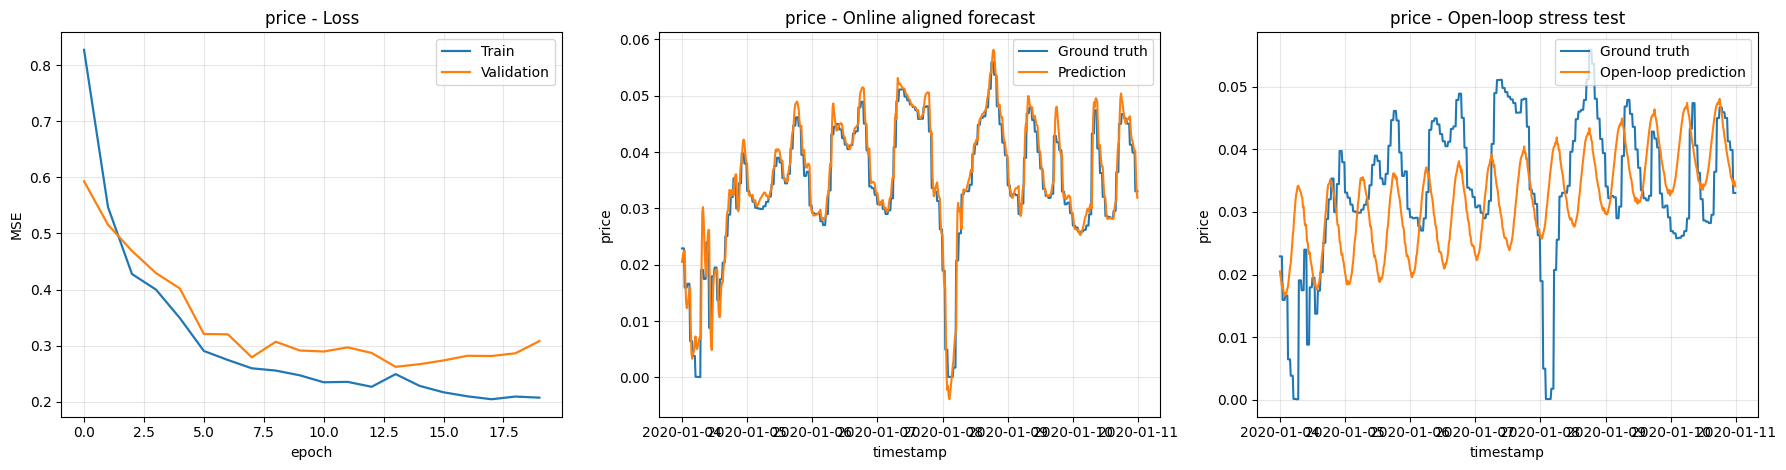

[price] best_val_loss = 0.262496
[price] artifact_paths = {'model_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\price\\price_lstm_h24.pt', 'meta_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\price\\price_lstm_h24_meta.json', 'scaler_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\price\\price_lstm_h24_scaler.pkl'}
[load] training starts
{'batch_size': 1024,
 'dropout': 0.1,
 'epochs': 20,
 'future_horizon': 24,
 'hidden_size': 96,
 'history_window': 288,
 'lr': 0.001,
 'num_layers': 2}
[forecast] load[SFH12]/household: train_segments=1, val_segments=1, columns=['load_SFH12'], train_stats={'min': 0.03765155375003815, 'max': 6.457228660583496, 'mean': 0.3157620429992676, 'std': 0.5169323682785034}, settings={'signal_name': 'load', 'history_window': 288, 'future_horizon': 24, 'hidden_size': 96, 'num_layers': 2, 'dropout': 0.1, 'batch_size': 1024, 'epoc

load[SFH12]/household epochs:   0%|          | 0/20 [00:00<?, ?it/s]

[forecast] artifact refreshed at C:\Users\10856\Desktop\GithubProject\MADRL_ESS\artifacts\forecast\lstm\h24\load\agent_0\household\load_agent0_lstm_h24_household.pt
[forecast] load[SFH12]/household metrics: online_rmse=0.437656, online_mae=0.197022, open_loop_rmse=0.568235, open_loop_mae=0.339901
[forecast] load[SFH12]/heatpump: train_segments=1, val_segments=1, columns=['load_SFH12'], train_stats={'min': 0.010437222197651863, 'max': 5.98427152633667, 'mean': 0.27050089836120605, 'std': 0.6856952905654907}, settings={'signal_name': 'load', 'history_window': 288, 'future_horizon': 24, 'hidden_size': 96, 'num_layers': 2, 'dropout': 0.1, 'batch_size': 1024, 'epochs': 20, 'lr': 0.001, 'train_ratio': 0.7, 'val_ratio': 0.15, 'device': 'cuda:0', 'model_mode': 'per_agent', 'time_feature_mode': 'hour_week_year', 'input_size': 7, 'postprocess_mode': 'baseline_blend', 'baseline_mode': 'last_value', 'blend_candidates': (0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0), 'scaler_type': 'robust

load[SFH12]/heatpump epochs:   0%|          | 0/20 [00:00<?, ?it/s]

[forecast] artifact refreshed at C:\Users\10856\Desktop\GithubProject\MADRL_ESS\artifacts\forecast\lstm\h24\load\agent_0\heatpump\load_agent0_lstm_h24_heatpump.pt
[forecast] load[SFH12]/heatpump metrics: online_rmse=0.937168, online_mae=0.600408, open_loop_rmse=0.911828, open_loop_mae=0.762232
[forecast] load[SFH14]/household: train_segments=1, val_segments=1, columns=['load_SFH14'], train_stats={'min': 0.04558299854397774, 'max': 3.84720778465271, 'mean': 0.2522754669189453, 'std': 0.30201828479766846}, settings={'signal_name': 'load', 'history_window': 288, 'future_horizon': 24, 'hidden_size': 96, 'num_layers': 2, 'dropout': 0.1, 'batch_size': 1024, 'epochs': 20, 'lr': 0.001, 'train_ratio': 0.7, 'val_ratio': 0.15, 'device': 'cuda:0', 'model_mode': 'per_agent', 'time_feature_mode': 'hour_week_year', 'input_size': 7, 'postprocess_mode': 'baseline_blend', 'baseline_mode': 'last_value', 'blend_candidates': (0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0), 'scaler_type': 'robust', 

...

[forecast] artifact refreshed at C:\Users\10856\Desktop\GithubProject\MADRL_ESS\artifacts\forecast\lstm\h24\load\agent_3\heatpump\load_agent3_lstm_h24_heatpump.pt
[forecast] load[SFH18]/heatpump metrics: online_rmse=0.787266, online_mae=0.513604, open_loop_rmse=0.831717, open_loop_mae=0.403269
[forecast] load[SFH20]/household: train_segments=1, val_segments=1, columns=['load_SFH20'], train_stats={'min': 0.0595112219452858, 'max': 4.880166053771973, 'mean': 0.3340824842453003, 'std': 0.389034241437912}, settings={'signal_name': 'load', 'history_window': 288, 'future_horizon': 24, 'hidden_size': 96, 'num_layers': 2, 'dropout': 0.1, 'batch_size': 1024, 'epochs': 20, 'lr': 0.001, 'train_ratio': 0.7, 'val_ratio': 0.15, 'device': 'cuda:0', 'model_mode': 'per_agent', 'time_feature_mode': 'hour_week_year', 'input_size': 7, 'postprocess_mode': 'baseline_blend', 'baseline_mode': 'last_value', 'blend_candidates': (0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0), 'scaler_type': 'robust', 'c

load[SFH20]/household epochs:   0%|          | 0/20 [00:00<?, ?it/s]

[forecast] artifact refreshed at C:\Users\10856\Desktop\GithubProject\MADRL_ESS\artifacts\forecast\lstm\h24\load\agent_4\household\load_agent4_lstm_h24_household.pt
[forecast] load[SFH20]/household metrics: online_rmse=0.287590, online_mae=0.127040, open_loop_rmse=0.413807, open_loop_mae=0.289096
[forecast] load[SFH20]/heatpump: train_segments=1, val_segments=1, columns=['load_SFH20'], train_stats={'min': 0.16290421783924103, 'max': 11.753623962402344, 'mean': 1.4979181289672852, 'std': 2.251244306564331}, settings={'signal_name': 'load', 'history_window': 288, 'future_horizon': 24, 'hidden_size': 96, 'num_layers': 2, 'dropout': 0.1, 'batch_size': 1024, 'epochs': 20, 'lr': 0.001, 'train_ratio': 0.7, 'val_ratio': 0.15, 'device': 'cuda:0', 'model_mode': 'per_agent', 'time_feature_mode': 'hour_week_year', 'input_size': 7, 'postprocess_mode': 'baseline_blend', 'baseline_mode': 'last_value', 'blend_candidates': (0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0), 'scaler_type': 'robust'

load[SFH20]/heatpump epochs:   0%|          | 0/20 [00:00<?, ?it/s]

[forecast] artifact refreshed at C:\Users\10856\Desktop\GithubProject\MADRL_ESS\artifacts\forecast\lstm\h24\load\agent_4\heatpump\load_agent4_lstm_h24_heatpump.pt
[forecast] load[SFH20]/heatpump metrics: online_rmse=4.375635, online_mae=3.448391, open_loop_rmse=3.506973, open_loop_mae=3.108010


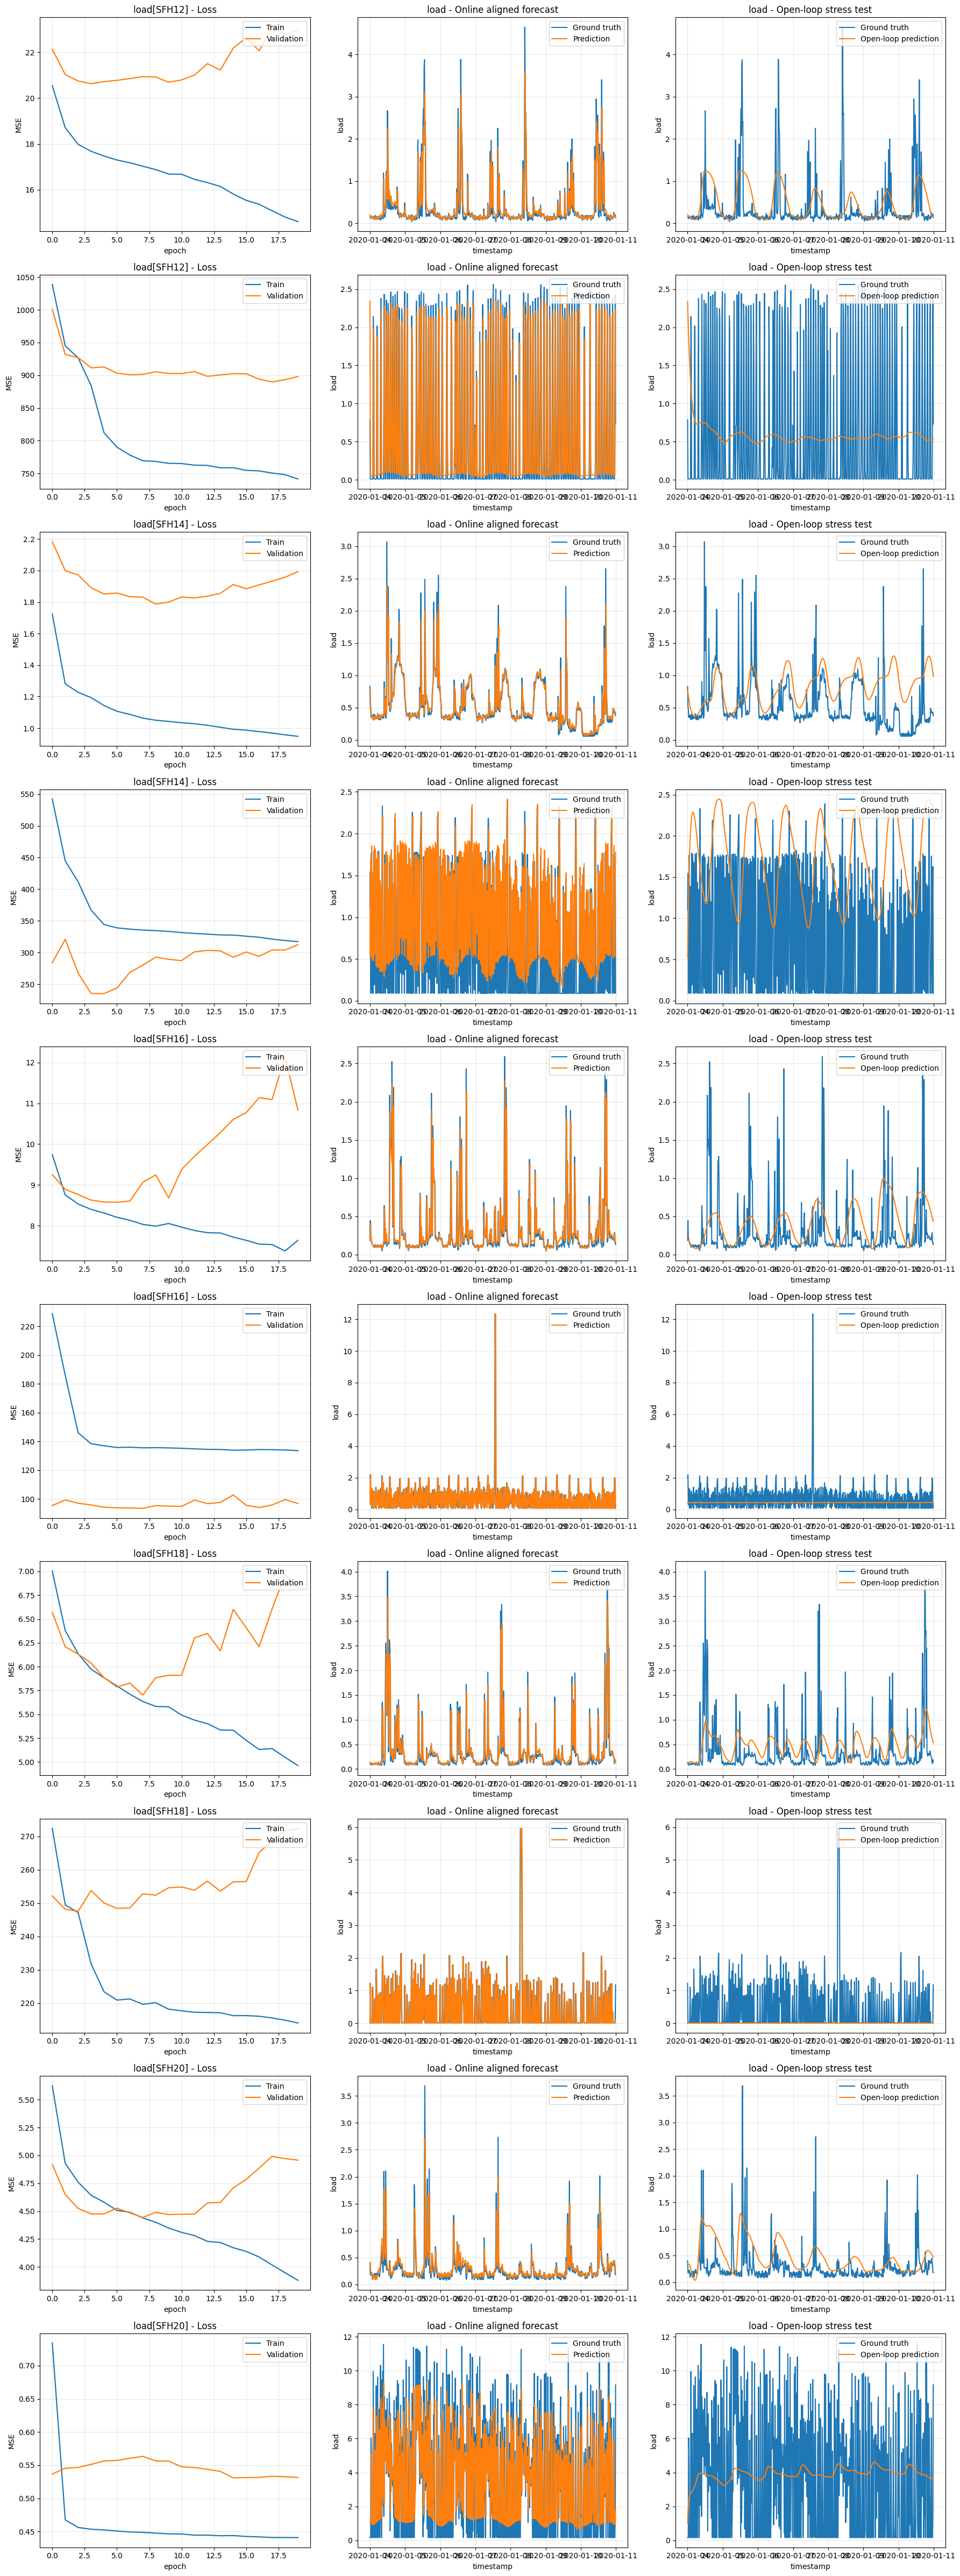

[load] best_val_loss = 150.778168
[load] agent=SFH12 best_val_loss=20.624664 blend_weight=0.3 artifact_paths={'model_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\load\\agent_0\\household\\load_agent0_lstm_h24_household.pt', 'meta_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\load\\agent_0\\household\\load_agent0_lstm_h24_household_meta.json', 'scaler_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\load\\agent_0\\household\\load_agent0_lstm_h24_household_scaler.pkl'}
[load] agent=SFH12 best_val_loss=889.803640 blend_weight=0.1 artifact_paths={'model_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\load\\agent_0\\heatpump\\load_agent0_lstm_h24_heatpump.pt', 'meta_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\load\\agent_0\\heatpump\\load_agent0_lstm_h24_heatpum

pv epochs:   0%|          | 0/20 [00:00<?, ?it/s]

[forecast] artifact refreshed at C:\Users\10856\Desktop\GithubProject\MADRL_ESS\artifacts\forecast\lstm\h24\pv\pv_lstm_h24.pt
[forecast] pv metrics: online_rmse=0.352694, online_mae=0.110651, open_loop_rmse=0.876390, open_loop_mae=0.454874


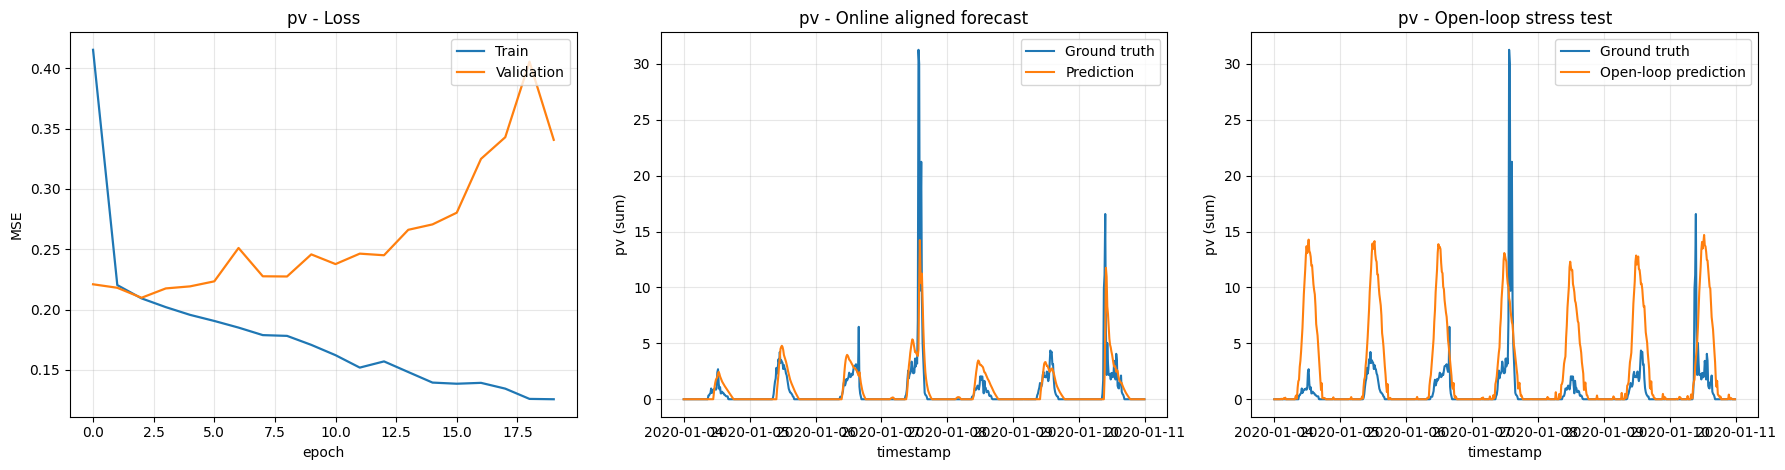

[pv] best_val_loss = 0.209812
[pv] artifact_paths = {'model_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\pv\\pv_lstm_h24.pt', 'meta_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\pv\\pv_lstm_h24_meta.json', 'scaler_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\pv\\pv_lstm_h24_scaler.pkl'}


In [6]:
reuse_saved_artifacts = globals().get("reuse_saved_artifacts", False)
require_complete_saved_artifacts = globals().get("require_complete_saved_artifacts", False)

results = {}
if reuse_saved_artifacts:
    results = load_results_from_saved_artifacts(
        require_complete=require_complete_saved_artifacts,
    )

signals_to_train = [signal_name for signal_name in signal_order if signal_name not in results]
if signals_to_train:
    if reuse_saved_artifacts:
        print(f"[section 2] retraining missing or incompatible signals: {signals_to_train}")
    for signal_name in signals_to_train:
        results[signal_name] = train_and_report_signal(signal_name)


In [7]:
artifact_map = collect_available_lstm_artifacts(cfg, overrides_by_signal=signal_training_overrides)

plot_path = None
signals_with_evaluation = [
    signal_name
    for signal_name in signal_order
    if signal_name in results and results[signal_name].get("evaluation") is not None
]
if len(signals_with_evaluation) == len(signal_order):
    plot_path = get_weekly_forecast_plot_path(
        future_horizon=cfg.env.future_horizon,
        root=cfg.forecast.lstm_artifact_root,
    )
    plot_weekly_forecasts(
        [results[signal_name]["evaluation"] for signal_name in signal_order],
        save_path=plot_path,
    )
else:
    skipped_signals = [signal_name for signal_name in signal_order if signal_name not in signals_with_evaluation]
    print(
        "[section 2] combined weekly plot skipped because these signals were reused "
        f"without fresh evaluation: {skipped_signals}"
    )

final_summary = {}
for signal_name in signal_order:
    if signal_name not in results:
        continue
    summary = {
        "settings": results[signal_name]["settings"],
        "artifact_paths": results[signal_name]["artifact_paths"],
        "loaded_from_artifacts": bool(results[signal_name].get("loaded_from_artifacts", False)),
    }
    training = results[signal_name].get("training")
    if training is not None:
        summary["best_val_loss"] = training["best_val_loss"]
    final_summary[signal_name] = summary

print("combined weekly plot:", plot_path if plot_path is not None else "skipped in reuse mode")
pprint(final_summary)
artifact_map


combined weekly plot: C:\Users\10856\Desktop\GithubProject\MADRL_ESS\artifacts\forecast\lstm\h24\plots\weekly_forecast_h24.png
{'load': {'artifact_paths': [{'meta_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\load\\agent_0\\household\\load_agent0_lstm_h24_household_meta.json',
                              'model_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\load\\agent_0\\household\\load_agent0_lstm_h24_household.pt',
                              'scaler_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\load\\agent_0\\household\\load_agent0_lstm_h24_household_scaler.pkl'},
                             {'meta_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\load\\agent_0\\heatpump\\load_agent0_lstm_h24_heatpump_meta.json',
                              'model_path': 'C:\\Users\\10856\\Desktop\\GithubProject

{'price': ('C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\price\\price_lstm_h24.pt',
  'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\price\\price_lstm_h24_meta.json',
  'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\price\\price_lstm_h24_scaler.pkl'),
 'load': [('C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\load\\agent_0\\household\\load_agent0_lstm_h24_household.pt',
   'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\load\\agent_0\\household\\load_agent0_lstm_h24_household_meta.json',
   'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\load\\agent_0\\household\\load_agent0_lstm_h24_household_scaler.pkl'),
  ('C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm\\h24\\load\\agent_0\\heatpump\\load_agent0_lstm_h24_heatpump.pt',
   '

## 3. MADRL Shared Data

`forecast_lstm.ipynb` now stops at managed LSTM artifact training and diagnostics.

MADRL shared train/test data is prepared on demand by the MADRL notebooks via `ensure_madrl_shared_data(...)` or by the CLI entrypoint `python -m scripts.utils.madrl_shared_data --cfg-json <path>`.

This notebook no longer exports full-year MADRL handoff artifacts and no longer warms observation caches.


## 4. Full Test-Set View with Ideal Warmup

The cell below draws one-step rolling predictions for `price`, `load`, and `pv` with two constraints:
- split the test set by `segment_id`
- keep the x-axis in the user-facing test period only

It assumes an ideal warmup: each prediction uses the latest real `history_window` points from the same test segment.


In [8]:
# Section 3 view controls
full_test_view_signals = ["price"]   # e.g. ["price"] or "load"
full_test_view_start_date = "20200729"             # e.g. "20200101" or "2020-01-01"
full_test_view_end_date = "20200805"               # e.g. "20200115" or "2020-01-15"


[section 3] signals = ['price']
[section 3] date range = 2020-07-29 to 2020-08-05


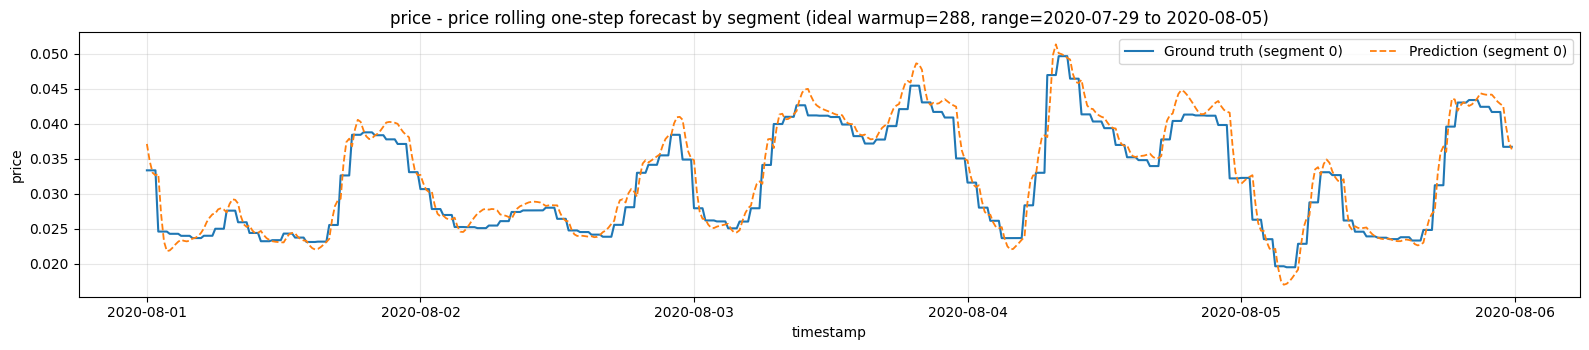

{'price': {'signal_name': 'price',
  'segments': [{'segment_id': 0,
    'timestamps': array([Timestamp('2020-08-01 00:00:00+0200', tz='Europe/Berlin'),
           Timestamp('2020-08-01 00:15:00+0200', tz='Europe/Berlin'),
           Timestamp('2020-08-01 00:30:00+0200', tz='Europe/Berlin'),
           Timestamp('2020-08-01 00:45:00+0200', tz='Europe/Berlin'),
           Timestamp('2020-08-01 01:00:00+0200', tz='Europe/Berlin'),
           Timestamp('2020-08-01 01:15:00+0200', tz='Europe/Berlin'),
           Timestamp('2020-08-01 01:30:00+0200', tz='Europe/Berlin'),
           Timestamp('2020-08-01 01:45:00+0200', tz='Europe/Berlin'),
           Timestamp('2020-08-01 02:00:00+0200', tz='Europe/Berlin'),
           Timestamp('2020-08-01 02:15:00+0200', tz='Europe/Berlin'),
           Timestamp('2020-08-01 02:30:00+0200', tz='Europe/Berlin'),
           Timestamp('2020-08-01 02:45:00+0200', tz='Europe/Berlin'),
           Timestamp('2020-08-01 03:00:00+0200', tz='Europe/Berlin'),
        

In [9]:
from predictors.lstm_forecaster import LSTMForecaster
from predictors.training import load_signal_matrix_from_source, resolve_signal_physical_scale_from_source
from data.loaders.prosumer import ProsumerDataset


def _normalize_full_test_view_signals(selection):
    available = {
        str(signal_name).strip().lower(): str(signal_name)
        for signal_name in signal_order
        if signal_name in results
    }
    if selection in (None, ""):
        return list(available.values())
    if isinstance(selection, str):
        raw_items = [item.strip() for item in selection.split(",") if item.strip()]
    else:
        raw_items = [str(item).strip() for item in selection if str(item).strip()]
    if not raw_items:
        return list(available.values())

    selected = []
    unknown = []
    for item in raw_items:
        normalized = item.lower()
        if normalized not in available:
            unknown.append(item)
            continue
        signal_name = available[normalized]
        if signal_name not in selected:
            selected.append(signal_name)
    if unknown:
        raise ValueError(
            f"Unsupported full_test_view_signals={unknown}. Available signals: {list(available.values())}."
        )
    return selected


def _coerce_compact_date_value(value):
    if isinstance(value, str):
        token = value.strip()
    elif isinstance(value, (int, np.integer)):
        token = str(int(value))
    elif isinstance(value, float) and float(value).is_integer():
        token = str(int(value))
    else:
        return value

    if token.isdigit() and len(token) == 8:
        return f"{token[:4]}-{token[4:6]}-{token[6:]}"
    return token if isinstance(value, str) else value


def _normalize_optional_local_date(value, label: str):
    if value in (None, ""):
        return None
    normalized_value = _coerce_compact_date_value(value)
    try:
        return pd.Timestamp(normalized_value).date()
    except Exception as exc:
        raise ValueError(
            f"{label} must be a local date like 20200101 or 2020-01-01, got {value!r}."
        ) from exc


def _resolve_full_test_view_date_range(start_date=None, end_date=None):
    date_range = {
        "start_date": _normalize_optional_local_date(start_date, "full_test_view_start_date"),
        "end_date": _normalize_optional_local_date(end_date, "full_test_view_end_date"),
    }
    if (
        date_range["start_date"] is not None
        and date_range["end_date"] is not None
        and date_range["start_date"] > date_range["end_date"]
    ):
        raise ValueError(
            "full_test_view_start_date must be <= full_test_view_end_date, got "
            f"{date_range['start_date']} > {date_range['end_date']}."
        )
    return date_range


def _format_full_test_view_date_range(date_range):
    start_date = date_range.get("start_date")
    end_date = date_range.get("end_date")
    if start_date is None and end_date is None:
        return "full test split"
    if start_date is not None and end_date is not None:
        return f"{start_date.isoformat()} to {end_date.isoformat()}"
    if start_date is not None:
        return f"from {start_date.isoformat()}"
    return f"through {end_date.isoformat()}"


def _build_local_date_mask(timestamps, date_range):
    if date_range["start_date"] is None and date_range["end_date"] is None:
        return None
    timestamp_series = pd.Series(timestamps).reset_index(drop=True)
    local_dates = timestamp_series.apply(lambda value: pd.Timestamp(value).date())
    mask = pd.Series(True, index=timestamp_series.index)
    if date_range["start_date"] is not None:
        mask &= local_dates >= date_range["start_date"]
    if date_range["end_date"] is not None:
        mask &= local_dates <= date_range["end_date"]
    return mask.to_numpy(dtype=bool)


def _filter_frame_and_values_by_date_range(frame, values, *, signal_name: str, date_range):
    if "timestamp" not in frame.columns:
        if date_range["start_date"] is None and date_range["end_date"] is None:
            return frame.reset_index(drop=True), np.asarray(values, dtype=np.float32)
        raise ValueError(
            f"signal={signal_name} does not expose a timestamp column, so date filtering is unavailable."
        )

    mask = _build_local_date_mask(frame["timestamp"], date_range)
    if mask is None:
        return frame.reset_index(drop=True), np.asarray(values, dtype=np.float32)

    filtered_frame = frame.loc[mask].reset_index(drop=True)
    filtered_values = np.asarray(values, dtype=np.float32)[mask]
    if filtered_frame.empty:
        raise ValueError(
            f"signal={signal_name} has no test rows inside {_format_full_test_view_date_range(date_range)}."
        )
    return filtered_frame, filtered_values


def _artifact_bundle_from_result(result):
    artifact_paths = result["artifact_paths"]
    if isinstance(artifact_paths, dict):
        return {
            "model_path": str(artifact_paths["model_path"]),
            "meta_path": str(artifact_paths["meta_path"]),
            "scaler_path": str(artifact_paths["scaler_path"]),
        }

    normalized_bundle = []
    for item in artifact_paths:
        if isinstance(item, dict):
            normalized_bundle.append(
                (
                    str(item["model_path"]),
                    str(item["meta_path"]),
                    str(item["scaler_path"]),
                )
            )
        else:
            model_path, meta_path, scaler_path = item
            normalized_bundle.append((str(model_path), str(meta_path), str(scaler_path)))
    return normalized_bundle


def _build_signal_forecaster_from_result(signal_name: str):
    artifact_bundle = _artifact_bundle_from_result(results[signal_name])
    if isinstance(artifact_bundle, dict):
        return LSTMForecaster.from_artifacts(
            model_path=artifact_bundle["model_path"],
            meta_path=artifact_bundle["meta_path"],
            scaler_path=artifact_bundle["scaler_path"],
            device=runtime_state.device,
            signal_name=signal_name,
        )
    return LSTMForecaster.from_signal_artifacts(
        {signal_name: artifact_bundle},
        device=runtime_state.device,
    )


def _load_component_test_signals(*, date_range):
    """Load component-level test signals for component split prediction."""
    data_dir = Path(cfg.data.data_dir or (project_root / "data"))
    from predictors.training import _resolve_prosumer_dataset_kwargs

    dataset_kwargs = _resolve_prosumer_dataset_kwargs(cfg, data_dir, "test")
    dataset = ProsumerDataset(**dataset_kwargs)
    mask = _build_local_date_mask(pd.Series(dataset._timestamps), date_range)
    comp_signals = {}
    for key, value in dataset._signals.items():
        if not key.startswith("load_"):
            continue
        signal_values = np.asarray(value, dtype=np.float32)
        if mask is not None:
            signal_values = signal_values[mask]
        comp_signals[key] = signal_values
    return comp_signals


def _build_signal_episode_meta(signal_name: str, source):
    physical_scale = resolve_signal_physical_scale_from_source(source, signal_name, split="test")
    if physical_scale is None:
        return None
    scale_values = np.asarray(physical_scale, dtype=np.float32).reshape(-1).tolist()
    if signal_name == "load":
        return {"load_scale": scale_values}
    if signal_name == "pv":
        return {"pv_peak_kw": scale_values}
    return None


def _rolling_test_predictions_with_ideal_warmup(signal_name: str, *, date_range):
    source = results[signal_name]["source"]
    test_frame, test_values, value_columns = load_signal_matrix_from_source(source, signal_name, split="test")
    test_frame, test_values = _filter_frame_and_values_by_date_range(
        test_frame,
        test_values,
        signal_name=signal_name,
        date_range=date_range,
    )
    forecaster = _build_signal_forecaster_from_result(signal_name)
    history_window = int(results[signal_name]["settings"]["history_window"])

    # For component split, supply component signals via set_episode.
    has_component_runtimes = any(
        getattr(r, "component", None) is not None
        for runtimes in forecaster.signal_runtimes.values()
        for r in runtimes
    )
    component_test_signals = None
    episode_meta = _build_signal_episode_meta(signal_name, source)
    if has_component_runtimes:
        component_test_signals = _load_component_test_signals(date_range=date_range)

    values = np.asarray(test_values, dtype=np.float32)
    if values.ndim == 1:
        values = values.reshape(-1, 1)

    working_frame = test_frame.copy()
    if "segment_id" not in working_frame.columns:
        working_frame["segment_id"] = 0
    working_frame["segment_id"] = working_frame["segment_id"].fillna(0).astype(int)

    segment_views = []
    for segment_id in sorted(working_frame["segment_id"].unique()):
        segment_mask = working_frame["segment_id"] == segment_id
        segment_frame = working_frame.loc[segment_mask].reset_index(drop=True)
        segment_values = values[segment_mask.to_numpy()]

        if segment_values.shape[0] <= history_window:
            print(
                f"[skip] signal={signal_name}, segment_id={segment_id}: "
                f"rows={segment_values.shape[0]} <= history_window={history_window} "
                f"within {_format_full_test_view_date_range(date_range)}"
            )
            continue

        timestamps = []
        target_rows = []
        prediction_rows = []

        for end_idx in range(history_window, segment_values.shape[0]):
            history = segment_values[end_idx - history_window:end_idx]
            history_timestamps = (
                segment_frame.iloc[end_idx - history_window:end_idx]["timestamp"].tolist()
                if "timestamp" in segment_frame.columns
                else None
            )
            step_episode_signals = {}
            if has_component_runtimes:
                step_episode_signals = {
                    key: value[end_idx - history_window:end_idx]
                    for key, value in component_test_signals.items()
                }
            if step_episode_signals or episode_meta is not None:
                forecaster.set_episode(step_episode_signals, episode_meta=episode_meta)

            rollout = forecaster.predict(
                history,
                horizon=2,
                signal_name=signal_name,
                history_timestamps=history_timestamps,
            )
            rollout = np.asarray(rollout, dtype=np.float32)

            if rollout.ndim == 1:
                prediction_rows.append(np.array([rollout[1]], dtype=np.float32))
            else:
                prediction_rows.append(rollout[:, 1].astype(np.float32))

            target_rows.append(segment_values[end_idx].astype(np.float32))
            timestamps.append(
                segment_frame.iloc[end_idx]["timestamp"] if "timestamp" in segment_frame.columns else end_idx
            )

        segment_views.append(
            {
                "segment_id": int(segment_id),
                "timestamps": np.asarray(timestamps),
                "target": np.stack(target_rows, axis=0),
                "prediction": np.stack(prediction_rows, axis=0),
            }
        )

    if not segment_views:
        raise ValueError(
            f"signal={signal_name} has no test segment long enough for history_window={history_window} "
            f"within {_format_full_test_view_date_range(date_range)}."
        )

    return {
        "signal_name": signal_name,
        "segments": segment_views,
        "value_columns": value_columns,
        "history_window": history_window,
        "date_range": date_range,
    }


selected_full_test_view_signals = _normalize_full_test_view_signals(full_test_view_signals)
full_test_view_date_range = _resolve_full_test_view_date_range(
    full_test_view_start_date,
    full_test_view_end_date,
)
print(f"[section 3] signals = {selected_full_test_view_signals}")
print(f"[section 3] date range = {_format_full_test_view_date_range(full_test_view_date_range)}")

full_test_views = {
    signal_name: _rolling_test_predictions_with_ideal_warmup(
        signal_name,
        date_range=full_test_view_date_range,
    )
    for signal_name in selected_full_test_view_signals
}

for signal_name in selected_full_test_view_signals:
    view = full_test_views[signal_name]
    n_users = len(view["value_columns"])
    figure, axes = plt.subplots(n_users, 1, figsize=(16, 3.6 * n_users), sharex=False)
    axes = np.atleast_1d(axes)

    for user_idx, axis in enumerate(axes):
        user_name = view["value_columns"][user_idx]
        for segment in view["segments"]:
            target_curve = segment["target"][:, user_idx]
            prediction_curve = segment["prediction"][:, user_idx]
            axis.plot(
                segment["timestamps"],
                target_curve,
                linewidth=1.5,
                label=f"Ground truth (segment {segment['segment_id']})",
            )
            axis.plot(
                segment["timestamps"],
                prediction_curve,
                linewidth=1.3,
                linestyle="--",
                label=f"Prediction (segment {segment['segment_id']})",
            )

        axis.set_title(
            f"{signal_name} - {user_name} rolling one-step forecast by segment "
            f"(ideal warmup={view['history_window']}, range={_format_full_test_view_date_range(view['date_range'])})"
        )
        axis.set_ylabel(user_name)
        axis.grid(True, alpha=0.3)
        axis.legend(loc="upper right", ncol=2)

    axes[-1].set_xlabel("timestamp")
    figure.tight_layout()
    plt.show()

full_test_views


## 5. Safe Legacy Artifact Cleanup

Preview the stale load artifacts first. Set `delete_stale_load_artifacts = True` and rerun the cell only when the list matches the legacy files you want to remove.


In [10]:
delete_stale_load_artifacts = False


def _artifact_bundle_paths(model_path: Path):
    return [
        model_path,
        model_path.with_name(f"{model_path.stem}_meta.json"),
        model_path.with_name(f"{model_path.stem}_scaler.pkl"),
    ]


def _legacy_load_artifact_candidates():
    artifact_root = Path(cfg.forecast.lstm_artifact_root or shared_settings["artifact_root"]).resolve()
    candidates = []
    candidates.extend(_artifact_bundle_paths(artifact_root / "h24" / "load" / "load_lstm_h24.pt"))
    for agent_index in range(int(cfg.env.num_agents)):
        candidates.extend(
            _artifact_bundle_paths(
                artifact_root
                / "h24"
                / "load"
                / f"agent_{agent_index}"
                / f"load_agent{agent_index}_lstm_h24.pt"
            )
        )
    legacy_h2_load_dir = artifact_root / "h2" / "load"
    if legacy_h2_load_dir.exists():
        candidates.extend(path for path in legacy_h2_load_dir.rglob("*") if path.is_file())

    deduped = []
    seen = set()
    for path in candidates:
        resolved = path.resolve()
        if resolved in seen:
            continue
        seen.add(resolved)
        deduped.append(resolved)
    return deduped


legacy_load_artifact_candidates = _legacy_load_artifact_candidates()
existing_legacy_load_artifacts = [path for path in legacy_load_artifact_candidates if path.exists()]
missing_legacy_load_artifacts = [path for path in legacy_load_artifact_candidates if not path.exists()]

print(f"[cleanup] artifact_root = {Path(cfg.forecast.lstm_artifact_root).resolve()}")
print(f"[cleanup] existing legacy files = {len(existing_legacy_load_artifacts)}")
for path in existing_legacy_load_artifacts:
    print(f" - {path}")
if missing_legacy_load_artifacts:
    print(f"[cleanup] already missing = {len(missing_legacy_load_artifacts)}")

if delete_stale_load_artifacts:
    for path in existing_legacy_load_artifacts:
        path.unlink()
    cleanup_dirs = sorted({path.parent for path in existing_legacy_load_artifacts}, key=lambda item: len(item.parts), reverse=True)
    for directory in cleanup_dirs:
        if directory.exists() and not any(directory.iterdir()):
            directory.rmdir()
    print(f"[cleanup] deleted {len(existing_legacy_load_artifacts)} legacy artifact files.")
else:
    print("[cleanup] preview only. Set delete_stale_load_artifacts = True and rerun this cell to delete them.")

existing_legacy_load_artifacts


[cleanup] artifact_root = C:\Users\10856\Desktop\GithubProject\MADRL_ESS\artifacts\forecast\lstm
[cleanup] existing legacy files = 15
 - C:\Users\10856\Desktop\GithubProject\MADRL_ESS\artifacts\forecast\lstm\h24\load\agent_0\load_agent0_lstm_h24.pt
 - C:\Users\10856\Desktop\GithubProject\MADRL_ESS\artifacts\forecast\lstm\h24\load\agent_0\load_agent0_lstm_h24_meta.json
 - C:\Users\10856\Desktop\GithubProject\MADRL_ESS\artifacts\forecast\lstm\h24\load\agent_0\load_agent0_lstm_h24_scaler.pkl
 - C:\Users\10856\Desktop\GithubProject\MADRL_ESS\artifacts\forecast\lstm\h24\load\agent_1\load_agent1_lstm_h24.pt
 - C:\Users\10856\Desktop\GithubProject\MADRL_ESS\artifacts\forecast\lstm\h24\load\agent_1\load_agent1_lstm_h24_meta.json
 - C:\Users\10856\Desktop\GithubProject\MADRL_ESS\artifacts\forecast\lstm\h24\load\agent_1\load_agent1_lstm_h24_scaler.pkl
 - C:\Users\10856\Desktop\GithubProject\MADRL_ESS\artifacts\forecast\lstm\h24\load\agent_2\load_agent2_lstm_h24.pt
 - C:\Users\10856\Desktop\Githu

[WindowsPath('C:/Users/10856/Desktop/GithubProject/MADRL_ESS/artifacts/forecast/lstm/h24/load/agent_0/load_agent0_lstm_h24.pt'),
 WindowsPath('C:/Users/10856/Desktop/GithubProject/MADRL_ESS/artifacts/forecast/lstm/h24/load/agent_0/load_agent0_lstm_h24_meta.json'),
 WindowsPath('C:/Users/10856/Desktop/GithubProject/MADRL_ESS/artifacts/forecast/lstm/h24/load/agent_0/load_agent0_lstm_h24_scaler.pkl'),
 WindowsPath('C:/Users/10856/Desktop/GithubProject/MADRL_ESS/artifacts/forecast/lstm/h24/load/agent_1/load_agent1_lstm_h24.pt'),
 WindowsPath('C:/Users/10856/Desktop/GithubProject/MADRL_ESS/artifacts/forecast/lstm/h24/load/agent_1/load_agent1_lstm_h24_meta.json'),
 WindowsPath('C:/Users/10856/Desktop/GithubProject/MADRL_ESS/artifacts/forecast/lstm/h24/load/agent_1/load_agent1_lstm_h24_scaler.pkl'),
 WindowsPath('C:/Users/10856/Desktop/GithubProject/MADRL_ESS/artifacts/forecast/lstm/h24/load/agent_2/load_agent2_lstm_h24.pt'),
 WindowsPath('C:/Users/10856/Desktop/GithubProject/MADRL_ESS/artifa

## Smoke Check

Suggested minimal smoke check:
1. set `full_test_view_signals = ["price"]`
2. set `full_test_view_start_date = "20200101"` and `full_test_view_end_date = "20200115"`
3. run section 3 and confirm only `price` is plotted for that date window
4. change `full_test_view_signals = ["load", "pv"]` and rerun section 3 to confirm only those two signals appear
5. run the cleanup preview cell with `delete_stale_load_artifacts = False` and confirm only legacy `load` artifacts are listed
